# AIS Ship Trajectory Analysis with GeoPandas
This notebook queries AIS vessel positions from a SQLite database and visualizes ship trajectories on interactive maps using GeoPandas.

## 1. Import Required Libraries

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx
import geodatasets
import warnings

# Add actint to path for imports
actint_path = Path("/home/daxtonb/JFN-Groundtruth-Tools/actint/src")
if str(actint_path) not in sys.path:
    sys.path.insert(0, str(actint_path))

from actint.data_processing.query_database import query_ais_positions, query_vessels

warnings.filterwarnings('ignore')

/home/daxtonb/.conda/envs/actint/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Connect to Database and Query Ship Positions

In [2]:
# Query positions for a specific ship (configure as needed)
# For example: query_ais_positions({"MMSI": "123456789"}) or {"vessel_id": value}

SHIP_QUERY = {"MMSI": 368011000}  # Change MMSI or column name as needed

try:
    ship_positions = query_ais_positions(SHIP_QUERY, sort=True)
    print(f"Retrieved {len(ship_positions)} positions")
    if ship_positions:
        print(f"Sample position: {ship_positions[0]}")
except Exception as e:
    print(f"Error querying database: {e}")
    ship_positions = []

2023-01-01T00:00:01.000000
Retrieved 1168 positions
Sample position: (10687, 368011000, '2023-01-01T23:59:17.000000', 33.08487, -118.49759, 10.9, 211.7, 511.0, 'USS KIDD', None, 'NKID', 90.0, 0.0, None, None, None, 0.0, 'A', '2026-02-26 03:51:09')


## 3. Convert Query Results to GeoDataFrame

In [3]:
def convert_to_geodataframe(query_results, lat_idx=3, lon_idx=4, timestamp_idx=2):
    """
    Convert query results to a GeoDataFrame.
    
    Parameters:
    - query_results: list of tuples from query_ais_positions
    - lat_idx: column index for latitude (default: 3)
    - lon_idx: column index for longitude (default: 4)
    - timestamp_idx: column index for timestamp (default: 2)
    
    Returns:
    - GeoDataFrame with geometry points
    """
    if not query_results:
        print("No query results to convert")
        return None
    
    # Convert tuples to list of dictionaries
    data = []
    for row in query_results:
        try:
            data.append({
                'latitude': float(row[lat_idx]),
                'longitude': float(row[lon_idx]),
                'timestamp': row[timestamp_idx],
                'raw_data': row
            })
        except (IndexError, ValueError, TypeError) as e:
            print(f"Skipping row due to error: {e}")
            continue
    
    if not data:
        print("No valid data points found")
        return None
        
    df = pd.DataFrame(data)
    
    # Create geometry column from coordinates
    geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
    
    print(f"Created GeoDataFrame with {len(gdf)} points")
    return gdf

# Convert the query results
if ship_positions:
    gdf = convert_to_geodataframe(ship_positions)
    if gdf is not None:
        print(gdf.head())
else:
    gdf = None
    print("No ship positions to convert")

Created GeoDataFrame with 1168 points
   latitude  longitude                   timestamp  \
0  33.08487 -118.49759  2023-01-01T23:59:17.000000   
1  33.08812 -118.49572  2023-01-01T23:58:12.000000   
2  33.08952 -118.49523  2023-01-01T23:57:07.000000   
3  33.09116 -118.49523  2023-01-01T23:56:01.000000   
4  33.09217 -118.49522  2023-01-01T23:54:57.000000   

                                            raw_data  \
0  (10687, 368011000, 2023-01-01T23:59:17.000000,...   
1  (10679, 368011000, 2023-01-01T23:58:12.000000,...   
2  (10671, 368011000, 2023-01-01T23:57:07.000000,...   
3  (10664, 368011000, 2023-01-01T23:56:01.000000,...   
4  (10658, 368011000, 2023-01-01T23:54:57.000000,...   

                      geometry  
0  POINT (-118.49759 33.08487)  
1  POINT (-118.49572 33.08812)  
2  POINT (-118.49523 33.08952)  
3  POINT (-118.49523 33.09116)  
4  POINT (-118.49522 33.09217)  


## 4. Visualize Ship Positions on Map

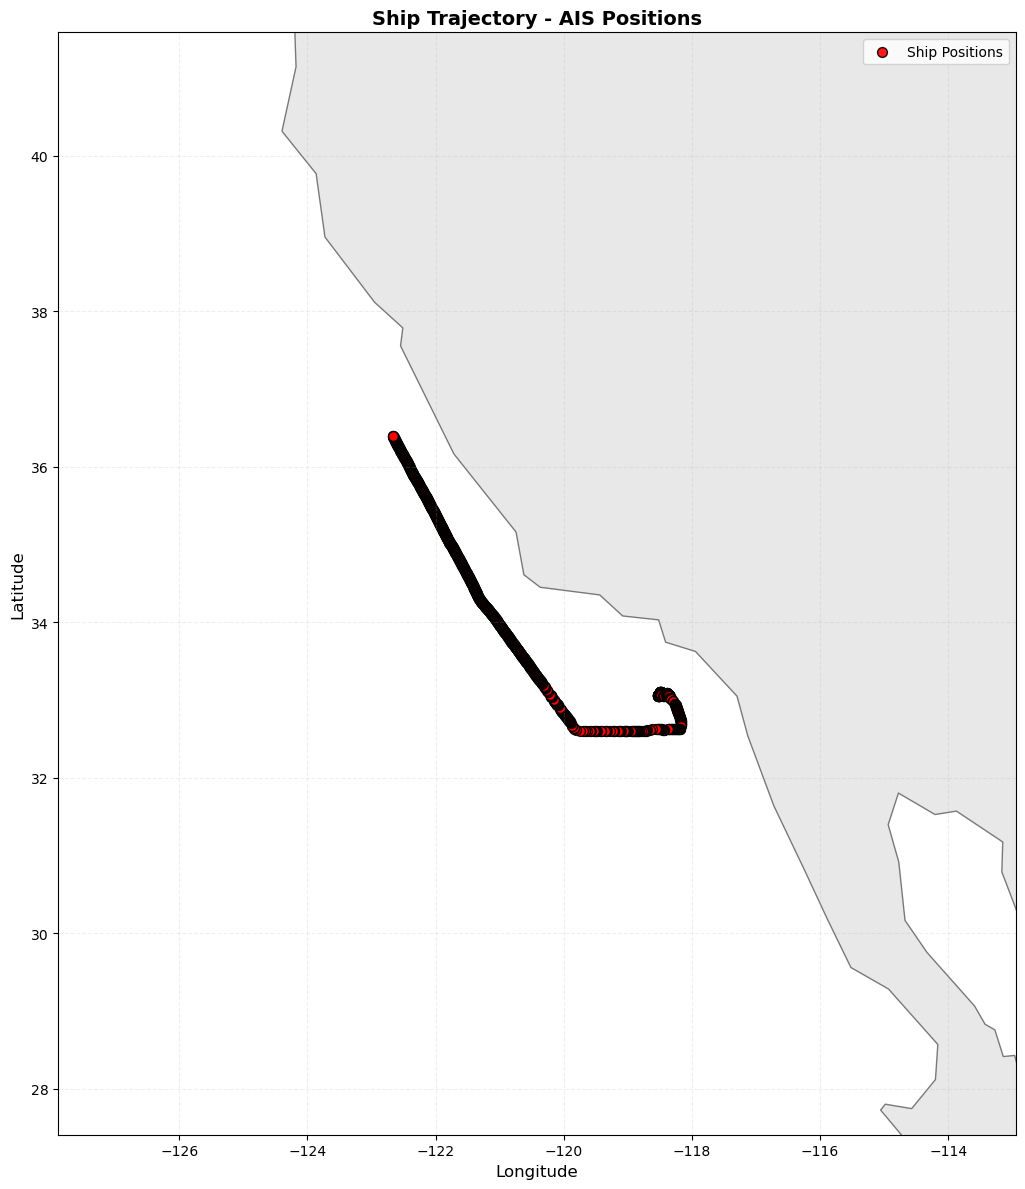

Map displayed with 1168 vessel positions
Latitude range: 32.5955 to 36.3954
Longitude range: -122.6682 to -118.1710


In [4]:
if gdf is not None and len(gdf) > 0:
    
    # Create a figure with matplotlib
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Load and plot world map as background
    world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
    world.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
    
    # Plot the ship positions on top
    gdf.plot(ax=ax, alpha=0.9, edgecolor='k', markersize=50, color='red', label='Ship Positions')
    
    # Zoom to the area covered by the data with a small margin
    xmin, ymin, xmax, ymax = gdf.total_bounds
    xmargin = (xmax - xmin) * 0.05 + 5
    ymargin = (ymax - ymin) * 0.05 + 5
    ax.set_xlim(xmin - xmargin, xmax + xmargin)
    ax.set_ylim(ymin - ymargin, ymax + ymargin)
    
    # Add grid
    ax.grid(True, alpha=0.2, linestyle='--')
    
    # Add labels
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'Ship Trajectory - AIS Positions', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Map displayed with {len(gdf)} vessel positions")
    print(f"Latitude range: {gdf['latitude'].min():.4f} to {gdf['latitude'].max():.4f}")
    print(f"Longitude range: {gdf['longitude'].min():.4f} to {gdf['longitude'].max():.4f}")
else:
    print("No GeoDataFrame to plot")

## 4b. Interactive Map with Numbered Markers (Folium)

In [9]:
import folium
from folium.plugins import MarkerCluster, PolyLineTextPath

# Create an interactive map centered on your data
if gdf is not None and len(gdf) > 0:
    center_lat = gdf['latitude'].mean()
    center_lon = gdf['longitude'].mean()
    
    # Create the map with OpenStreetMap tiles
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=6,
        tiles='OpenStreetMap'
    )
    
    # Add numbered markers
    for idx, row in gdf.iterrows():
        marker_number = idx + 1
        
        # Create popup with detailed information
        popup_text = f"""
        <b>Marker #{marker_number}</b><br>
        Latitude: {row['latitude']:.6f}<br>
        Longitude: {row['longitude']:.6f}<br>
        Timestamp: {row['timestamp']}
        """
        
        # Add marker with number
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=folium.Popup(popup_text, max_width=300),
            tooltip=f"Point #{marker_number}",
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(m)
        
        # Add circle with number label
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=10,
            popup=f"Marker #{marker_number}",
            color='blue',
            fill=True,
            fillColor='lightblue',
            fillOpacity=0.7,
            weight=2
        ).add_to(m)
    
    # Add polyline connecting all points in order
    if len(gdf) > 1:
        line_coords = [[row['latitude'], row['longitude']] for idx, row in gdf.iterrows()]
        folium.PolyLine(
            locations=line_coords,
            color='red',
            weight=2,
            opacity=0.7,
            popup='Ship Trajectory'
        ).add_to(m)
    
    # Fit bounds to show all markers
    bounds = [[gdf['latitude'].min(), gdf['longitude'].min()], 
              [gdf['latitude'].max(), gdf['longitude'].max()]]
    m.fit_bounds(bounds)
    
    # Display the map
    m
    
    print(f"Interactive map created with {len(gdf)} numbered markers")
    print(f"Features: Click markers for details, zoom with mouse wheel, drag to pan")
else:
    print("No GeoDataFrame to map")

Interactive map created with 1168 numbered markers
Features: Click markers for details, zoom with mouse wheel, drag to pan


## 5. Filter and Analyze Multiple Ship Trajectories

In [6]:
def plot_multiple_ships(ship_queries, lat_idx=3, lon_idx=4, timestamp_idx=2):
    """
    Query and plot multiple ship trajectories on the same map.
    
    Parameters:
    - ship_queries: list of dictionaries with query parameters
    - lat_idx, lon_idx, timestamp_idx: column indices
    """
    fig, ax = plt.subplots(figsize=(18, 14))
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    
    # Load and plot world map as background
    world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
    world.plot(ax=ax, color='lightgray', edgecolor='black', alpha=0.5)
    
    for i, query in enumerate(ship_queries):
        try:
            positions = query_ais_positions(query, sort=True)
            gdf_ship = convert_to_geodataframe(positions, lat_idx, lon_idx, timestamp_idx)
            
            if gdf_ship is not None and len(gdf_ship) > 0:
                color = colors[i % len(colors)]
                gdf_ship.plot(ax=ax, alpha=0.7, color=color, markersize=30, label=f"Ship {i+1}")
                print(f"Plotted {len(gdf_ship)} positions for query: {query}")
        except Exception as e:
            print(f"Error plotting ship {i+1}: {e}")
    
    # Add grid
    ax.grid(True, alpha=0.2, linestyle='--')
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Multiple Ship Trajectories - AIS Positions', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

# Example: Plot multiple ships
# Uncomment and modify the queries below to compare multiple vessels
SHIP_QUERIES = [
    {"MMSI": "123456789"},
    # {"MMSI": "987654321"},
    # Add more queries as needed
]

if len(SHIP_QUERIES) > 1:
    plot_multiple_ships(SHIP_QUERIES)
else:
    print("Add multiple ship queries to plot_multiple_ships(SHIP_QUERIES) to compare trajectories")

Add multiple ship queries to plot_multiple_ships(SHIP_QUERIES) to compare trajectories


## 6. Interactive Map for Multiple Ships (Folium)

In [ ]:
def plot_multiple_ships_interactive(ship_queries, lat_idx=3, lon_idx=4, timestamp_idx=2):
    """
    Query and plot multiple ship trajectories on an interactive Folium map.
    
    Parameters:
    - ship_queries: list of dictionaries with query parameters
    - lat_idx, lon_idx, timestamp_idx: column indices
    
    Returns:
    - Folium map object
    """
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    all_gdfs = []
    
    # Query all ships
    for i, query in enumerate(ship_queries):
        try:
            positions = query_ais_positions(query, sort=True)
            gdf_ship = convert_to_geodataframe(positions, lat_idx, lon_idx, timestamp_idx)
            
            if gdf_ship is not None and len(gdf_ship) > 0:
                all_gdfs.append({
                    'gdf': gdf_ship,
                    'query': query,
                    'color': colors[i % len(colors)],
                    'index': i
                })
                print(f"Loaded {len(gdf_ship)} positions for query: {query}")
        except Exception as e:
            print(f"Error loading ship {i+1}: {e}")
    
    if not all_gdfs:
        print("No data loaded for any ships")
        return None
    
    # Calculate center point
    all_lats = []
    all_lons = []
    for ship_data in all_gdfs:
        all_lats.extend(ship_data['gdf']['latitude'].tolist())
        all_lons.extend(ship_data['gdf']['longitude'].tolist())
    
    center_lat = sum(all_lats) / len(all_lats)
    center_lon = sum(all_lons) / len(all_lons)
    
    # Create the map
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=6,
        tiles='OpenStreetMap'
    )
    
    # Add data for each ship
    marker_counter = 1
    for ship_data in all_gdfs:
        gdf = ship_data['gdf']
        color = ship_data['color']
        ship_index = ship_data['index']
        
        # Create a feature group for this ship
        fg = folium.FeatureGroup(name=f"Ship {ship_index + 1}")
        
        # Add markers and trajectory line
        line_coords = []
        for idx, row in gdf.iterrows():
            lat, lon = row['latitude'], row['longitude']
            line_coords.append([lat, lon])
            
            popup_text = f"""
            <b>Ship {ship_index + 1} - Marker #{marker_counter}</b><br>
            Latitude: {lat:.6f}<br>
            Longitude: {lon:.6f}<br>
            Timestamp: {row['timestamp']}
            """
            
            folium.CircleMarker(
                location=[lat, lon],
                radius=8,
                popup=folium.Popup(popup_text, max_width=300),
                tooltip=f"Ship {ship_index + 1} - #{marker_counter}",
                color=color,
                fill=True,
                fillColor=color,
                fillOpacity=0.7,
                weight=2
            ).add_to(fg)
            
            marker_counter += 1
        
        # Add polyline for trajectory
        if len(line_coords) > 1:
            folium.PolyLine(
                locations=line_coords,
                color=color,
                weight=2,
                opacity=0.7,
                popup=f"Ship {ship_index + 1} Trajectory"
            ).add_to(fg)
        
        fg.add_to(m)
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    # Fit bounds
    bounds = [[min(all_lats), min(all_lons)], 
              [max(all_lats), max(all_lons)]]
    m.fit_bounds(bounds, padding=(0.1, 0.1))
    
    return m

# Example: Create interactive map for multiple ships
INTERACTIVE_QUERIES = [
    {"MMSI": 368011000},
    # {"MMSI": "987654321"},
    # Add more queries as needed
]

if len(INTERACTIVE_QUERIES) >= 1:
    interactive_map = plot_multiple_ships_interactive(INTERACTIVE_QUERIES)
    if interactive_map:
        interactive_map
        print("Interactive map created! Use layer control (top right) to show/hide ships")
else:
    print("Add ship queries to INTERACTIVE_QUERIES to create an interactive comparison map")